
# Do LLMs know the difference between a pet chicken and a roast chicken?

## Word sense disambiguation in computational models and humans


In human language, words do not always have a fixed meaning. The most striking example is homonymous words: words that have the same form, but very different meanings. For instance, the word "bank", which has a different meaning in the context "I went to the bank to get some money" and "At the river bank, I met my old friend". Polysemous words are words that have different -- yet related -- meanings: for example, "chicken" is the same 'entity' in "My pet chicken is lovely" and "I am having roast chicken for dinner", but has very different meanings in these two contexts. In general, context can modulate almost any word's meaning. This poses a challenge in computational linguistics, as we need to find a way to differentiate among different meanings like humans do. Much research, resources, and models have been put forward to help with this challenge.

In this assignment, you are going to focus on [Trott and Bergen's (2021)](https://aclanthology.org/2021.acl-long.550/) RAW-C dataset: you are going to conduct a number of explorations with this dataset and partially replicate their research by the end of the assignment. In short, the authors explore how good LLMs are at capturing same/different meanings of words across contexts by comparing it to human judgements. To better understand the idea and the research, start by reading the paper.

This assignment entails a series of (interconnected) tasks (altogether worth 95 points):

* **Task 1**. Compute contextual word embeddings at different layers from Trott & Bergen's dataset. Here, each word is found in 4 sentences: 2 with one meaning, 2 with another meaning.
* **Task 2**. Compute sense embeddings for words in Trott & Bergen's dataset using WordNet, so you have an embedding for each definition of the word.
* **Task 3**. Compute the similarity between the contextual word embeddings of the homonyms at different layers and their sense embeddings; explore the relationship between homonyms and dominant senses quantitatively and qualitatively
* **Task 4**. Replicate part of Trott & Bergen's work by computing similarities across sentences with same/different meanings at the different layers and correlate with human similarities; visualise the results and reflect on them

In order to better understand the assignment, we recommend going through it all before starting so that it is clear how each part is connected to the next (which will help you make decisions about data structures, for instance).

# Task 1: Compute contextual word embeddings for homonyms [20 points]

## Task 1.1: read, explore and extract the necessary data [5 points]

First, you will have to (fork and) clone the github repository that stores the data you'll need. This can be found here: https://github.com/sashakenjeeva/raw-c . The repo also includes a README with a description of the original files in the repository, as well as some notes relevant for this assignment specifically.

In [21]:
# Task 0 / setup: environment, dependencies, paths
import importlib
import os
import subprocess
import sys
from pathlib import Path

# This avoids a Windows OpenMP duplicate-runtime crash observed in the local environment.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ.setdefault("PYTHONIOENCODING", "utf-8")
try:
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

PROJECT_ROOT = Path.cwd()
RAW_C_DIR = PROJECT_ROOT / "raw-c"
DATA_PATH = RAW_C_DIR / "data" / "processed" / "raw-c.csv"
STIMULI_PATH = RAW_C_DIR / "data" / "stims" / "stimuli.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# If BERT is already cached locally, stay offline to avoid repeated network retries.
HF_BERT_CACHE = Path.home() / ".cache" / "huggingface" / "hub" / "models--bert-base-uncased"
HF_LOCAL_ONLY = HF_BERT_CACHE.exists()
if HF_LOCAL_ONLY:
    os.environ["HF_HUB_OFFLINE"] = "1"
    os.environ["TRANSFORMERS_OFFLINE"] = "1"


def ensure_module(module_name, install_name=None):
    """Import a module, installing it only if it is missing."""
    try:
        return importlib.import_module(module_name)
    except ModuleNotFoundError:
        package = install_name or module_name
        print(f"Installing missing package: {package}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        return importlib.import_module(module_name)

# Core dependencies used throughout the notebook.
for module_name, install_name in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("scipy", "scipy"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("nltk", "nltk"),
    ("torch", "torch"),
    ("transformers", "transformers"),
    ("datasets", "datasets"),
]:
    ensure_module(module_name, install_name)

try:
    from psycho_embeddings import ContextualizedEmbedder
    PSYCHO_EMBEDDINGS_BACKEND = "psycho_embeddings package"
except Exception as exc:
    print("Could not import psycho_embeddings; installing from source and retrying.")
    print("Original import error:", repr(exc))
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--force-reinstall",
        "--no-deps",
        "git+https://github.com/MilaNLProc/psycho-embeddings.git",
    ])
    from psycho_embeddings import ContextualizedEmbedder
    PSYCHO_EMBEDDINGS_BACKEND = "psycho_embeddings package reinstalled from source"

import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

if not RAW_C_DIR.exists():
    subprocess.check_call(["git", "clone", "https://github.com/sashakenjeeva/raw-c.git", str(RAW_C_DIR)])

print("Project root:", PROJECT_ROOT)
print("RAW-C data path:", DATA_PATH, "exists=", DATA_PATH.exists())
print("Original stimuli path:", STIMULI_PATH, "exists=", STIMULI_PATH.exists())
print("Output directory:", OUTPUT_DIR)
print("BERT local cache detected:", HF_LOCAL_ONLY)
print("Embedding backend:", PSYCHO_EMBEDDINGS_BACKEND)

Project root: c:\Users\digitalnomad\Downloads\projectcl
RAW-C data path: c:\Users\digitalnomad\Downloads\projectcl\raw-c\data\processed\raw-c.csv exists= True
Original stimuli path: c:\Users\digitalnomad\Downloads\projectcl\raw-c\data\stims\stimuli.csv exists= True
Output directory: c:\Users\digitalnomad\Downloads\projectcl\outputs
BERT local cache detected: True
Embedding backend: psycho_embeddings package


Make sure you mount the drive now so that you have access to the folder (think about setting the working directory in a way that is convenient).

In [22]:
# In Colab this is where Drive mounting would normally happen.
# I keep the notebook path-based, so it works both locally and in Colab after the RAW-C repo is cloned.
import os
from pathlib import Path

print("Current working directory:", Path.cwd())
print("Files in current directory:")
for item in sorted(Path.cwd().iterdir()):
    print(" -", item.name)

Current working directory: c:\Users\digitalnomad\Downloads\projectcl
Files in current directory:
 - 18.md
 - 18.pdf
 - 2021.acl-long.550.md
 - 2021.acl-long.550.pdf
 - compling26_assignment (1).ipynb
 - compling26_assignment (1).py
 - outputs
 - raw-c


Now, you will have to read the data and organise it in a structure that works for the next parts of the assignment.

Read and explore the dataframe to see its structure (print part of it). What we need from it are the homonyms (in the form that they appear in the sentence -- the lexeme -- and in their regular form -- the lemma) and their corresponding sentences with different meanings (M1_a and M1_b have same meaning; M2_a, M2_b have same meaning). We only will need the stimuli that are in the final RAW-C dataset, as this is what we'll replicate at the end.

You can decide which data structure to use, but make sure that all these pieces of information are there (the word, the string, the meaning id, and the corresponding sentences) and easy to retrieve. Show your data at the end, as well as how many stimuli you end up with.

In [23]:
# Task 1.1: read final RAW-C data and reconstruct one row per word/context.
import pandas as pd
from IPython.display import display

raw_df = pd.read_csv(DATA_PATH)
print("RAW-C dataframe shape:", raw_df.shape)
print("Number of rows:", len(raw_df))
print("Number of unique words:", raw_df["word"].nunique())
print("Rows per word value counts:")
print(raw_df.groupby("word").size().value_counts().sort_index())
display(raw_df.head())

assert len(raw_df) == 672, "The final RAW-C dataset should contain 672 sentence-pair rows."
assert raw_df["word"].nunique() == 112, "The final RAW-C dataset should contain 112 unique words."
assert set(raw_df.groupby("word").size().unique()) == {6}, "Each word should have exactly six pair rows."

records = []
for _, row in raw_df.iterrows():
    for sentence_col, meaning_col in [("sentence1", "v1"), ("sentence2", "v2")]:
        records.append({
            "word": row["word"],
            "string": row["string"],
            "meaning_id": row[meaning_col],
            "sentence": row[sentence_col],
            "ambiguity_type": row["ambiguity_type"],
            "Class": row["Class"],
        })

stimuli_df = (
    pd.DataFrame(records)
    .drop_duplicates(["word", "meaning_id", "sentence"])
    .sort_values(["word", "meaning_id"])
    .reset_index(drop=True)
)

expected_meaning_ids = {"M1_a", "M1_b", "M2_a", "M2_b"}
print("Reconstructed stimulus dataframe shape:", stimuli_df.shape)
print("Number of reconstructed contexts:", len(stimuli_df))
print("Unique words in reconstructed contexts:", stimuli_df["word"].nunique())
meaning_counts = stimuli_df.groupby("word")["meaning_id"].nunique()
print("Meaning-id counts per word:")
print(meaning_counts.value_counts().sort_index())

missing_target_rows = stimuli_df[
    ~stimuli_df.apply(lambda r: str(r["string"]).lower() in str(r["sentence"]).lower(), axis=1)
]
print("Rows where the target string is not a simple case-insensitive substring of the sentence:", len(missing_target_rows))
if len(missing_target_rows):
    display(missing_target_rows.head(10))

assert len(stimuli_df) == 448, "There should be four contexts for each of 112 words."
assert stimuli_df["word"].nunique() == 112
assert meaning_counts.eq(4).all()
assert set(stimuli_df["meaning_id"].unique()) == expected_meaning_ids

print("Preview of the data structure used for the rest of the assignment:")
display(stimuli_df.head(12))
print("Bank contexts:")
display(stimuli_df[stimuli_df["word"] == "bank"])

RAW-C dataframe shape: (672, 20)
Number of rows: 672
Number of unique words: 112
Rows per word value counts:
6    112
Name: count, dtype: int64


,word,sentence1,sentence2,same,ambiguity_type,disambiguating_word1,disambiguating_word2,version,Class,mean_relatedness,median_relatedness,diff,count,sd_relatedness,distance_bert,distance_elmo,se_relatedness,v1,v2,string
0,act,It was a desperate act.,It was a magic act.,False,Polysemy,desperate,magic,M1_a_M2_a,N,2.181818,2.0,0.181818,11,1.328020,0.204110,0.034093,0.400413,M1_a,M2_a,act
1,act,It was a desperate act.,It was a comedic act.,False,Polysemy,desperate,comedic,M1_a_M2_b,N,2.000000,2.0,0.000000,7,1.290994,0.215616,0.045927,0.487950,M1_a,M2_b,act
2,act,It was a humane act.,It was a magic act.,False,Polysemy,humane,magic,M1_b_M2_a,N,2.818182,3.0,0.181818,11,0.981650,0.191488,0.042351,0.295979,M1_b,M2_a,act
3,act,It was a humane act.,It was a comedic act.,False,Polysemy,humane,comedic,M1_b_M2_b,N,2.809524,3.0,0.190476,21,0.928388,0.225272,0.057707,0.202591,M1_b,M2_b,act
4,act,It was a desperate act.,It was a humane act.,True,Polysemy,desperate,humane,M1_a_M1_b,N,3.900000,4.0,0.100000,10,0.316228,0.167990,0.041440,0.100000,M1_a,M1_b,act


Reconstructed stimulus dataframe shape: (448, 6)
Number of reconstructed contexts: 448
Unique words in reconstructed contexts: 112
Meaning-id counts per word:
meaning_id
4    112
Name: count, dtype: int64
Rows where the target string is not a simple case-insensitive substring of the sentence: 0
Preview of the data structure used for the rest of the assignment:


,word,string,meaning_id,sentence,ambiguity_type,Class
0,act,act,M1_a,It was a desperate act.,Polysemy,N
1,act,act,M1_b,It was a humane act.,Polysemy,N
2,act,act,M2_a,It was a magic act.,Polysemy,N
3,act,act,M2_b,It was a comedic act.,Polysemy,N
4,appeal,appeal,M1_a,He had a universal appeal.,Polysemy,N
5,appeal,appeal,M1_b,He had an undefinable appeal.,Polysemy,N
6,appeal,appeal,M2_a,He had a legal appeal.,Polysemy,N
7,appeal,appeal,M2_b,He had a pending appeal.,Polysemy,N
8,atmosphere,atmosphere,M1_a,It was a tense atmosphere.,Polysemy,N
9,atmosphere,atmosphere,M1_b,It was a hostile atmosphere.,Polysemy,N


Bank contexts:


,word,string,meaning_id,sentence,ambiguity_type,Class
20,bank,banked,M1_a,He banked the plane.,Homonymy,V
21,bank,banked,M1_b,He banked the helicopter.,Homonymy,V
22,bank,banked,M2_a,He banked the money.,Homonymy,V
23,bank,banked,M2_b,He banked the cash.,Homonymy,V


## Task 1.2: Compute the contextualised word embeddings [15 points]


Now that you have the homonyms and their corresponding sentences, we will need to compute word embeddings for each of them. For this we will use the BERT base model, in its uncased version.

That is, for each homonym, you will have to compute four embeddings: one for the homonym in M1_a, one in M1_b, one in M2_a, one in M2_b. However, we also want to look into different layers of the BERT model to see which one captures the homonym's meaning best: you want to calculate embeddings at the static layer and at layers 4, 8, 12.

We will use the package psycho-embeddings (you will use it in class), which allows us to specify which target words we want to obtain the embeddings of, in which sentences, and at which layers, among other things. Make sure to read the documentation of the package so that you know the meaning of the arguments and which ones will come useful to you.

First of all, install the psycho-embeddings package below.

In [24]:
# Task 1.2 setup: psycho-embeddings was installed/repaired in the first setup cell if necessary.
from psycho_embeddings import ContextualizedEmbedder
print("ContextualizedEmbedder import succeeded:", ContextualizedEmbedder)

ContextualizedEmbedder import succeeded: <class 'psycho_embeddings.embedder.ContextualizedEmbedder'>


Now, import the relevant module/function from psycho-embeddings and load the required BERT model.

In [25]:
# Import the embedder and load BERT base uncased.
import numpy as np
import torch
from transformers import AutoModel, AutoTokenizer
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
MODEL_NAME = "bert-base-uncased"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# The assignment can run on GPU, but this local environment is CPU-only.
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Using device:", DEVICE)

embedder = ContextualizedEmbedder(MODEL_NAME, max_length=128, device=DEVICE)
print("Loaded model:", MODEL_NAME)
print("Number of BERT encoder layers:", len(embedder.model.encoder.layer))
print("Hidden size:", embedder.model.config.hidden_size)

Torch version: 2.10.0+cpu
CUDA available: False
Using device: cpu
Loaded model: bert-base-uncased
Number of BERT encoder layers: 12
Hidden size: 768


Now, test that everything works correctly by computing an embedding for the word "assignment" in the sentence "I am having so much fun with this assignment!", at static layer and layers 4, 8 and 12 (hint: think of tokenisation and how the embedder deals with that).

In [26]:
# Test extraction on a simple example before running the full RAW-C batch.
assignment_embeddings = embedder.embed(
    words=["assignment"],
    target_texts=["I am having so much fun with this assignment!"],
    layers_id=[4, 8, 12],
    batch_size=1,
    show_progress=False,
    averaging=True,
    return_static=True,
)

print("Returned layer keys:", sorted(assignment_embeddings.keys()))
for layer_key in sorted(assignment_embeddings.keys()):
    vector = np.asarray(assignment_embeddings[layer_key][0])
    print(f"Layer {layer_key}: shape={vector.shape}, first five values={np.round(vector[:5], 4)}")

assert set(assignment_embeddings.keys()) == {-1, 4, 8, 12}
assert all(np.asarray(v[0]).shape == (768,) for v in assignment_embeddings.values())

Text tokenization:   0%|          | 0/1 [00:00<?, ? examples/s]

Returned layer keys: [-1, 4, 8, 12]
Layer -1: shape=(768,), first five values=[-0.0094 -0.0577 -0.0616 -0.0536 -0.0078]
Layer 4: shape=(768,), first five values=[ 1.9968 -0.591  -0.1317 -0.5903  0.7785]
Layer 8: shape=(768,), first five values=[ 1.0264 -0.6431 -0.3829 -0.276   0.2697]
Layer 12: shape=(768,), first five values=[ 0.3949 -0.3286 -0.1683  0.0146  0.0804]


c:\Users\digitalnomad\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


The next step is to calculate embeddings for the homonyms and their sentences that we got from the RAW-C dataset.

Make sure that your final output includes the word, the meaning id (M1_a, etc), the corresponding sentence and the embeddings at static layer and layers 4, 8, 12. You should maximally optimise this process by calculating in batches (again, check psycho-embeddings documentation), but keep in mind this might still take a while. First test your pipeline with a small number of inputs, and only run the full scale embedding extraction once you're positive the code works as expected.

When done, save the output in [pickle](https://docs.python.org/3/library/pickle.html) format (this is similar to json, but it can also handle np.arrays), so that you can easily load it later when needed and do not have to run it again. After pickle dumping (that's the word for saving it in pickle format), print it so that you are sure everything was saved correctly.

Then, check that your final data includes everything that you need by checking the entry "bank" and print the data pertaining to "bank".

In [27]:
# Compute contextual word embeddings for all RAW-C contexts, or load them if already saved.
import pickle

contextual_path = OUTPUT_DIR / "rawc_contextual_embeddings.pkl"
layer_ids = [4, 8, 12]
embedding_columns = ["embedding_static", "embedding_4", "embedding_8", "embedding_12"]

if contextual_path.exists():
    with contextual_path.open("rb") as f:
        contextual_embeddings_df = pickle.load(f)
    print("Loaded contextual embeddings from:", contextual_path)
else:
    sample_df = stimuli_df.head(8).copy()
    sample_embeddings = embedder.embed(
        words=sample_df["string"].tolist(),
        target_texts=sample_df["sentence"].tolist(),
        layers_id=layer_ids,
        batch_size=8,
        show_progress=True,
        averaging=True,
        return_static=True,
    )
    print("Small-pipeline test shapes:")
    print({layer: np.asarray(values[0]).shape for layer, values in sample_embeddings.items()})

    batch_embeddings = embedder.embed(
        words=stimuli_df["string"].tolist(),
        target_texts=stimuli_df["sentence"].tolist(),
        layers_id=layer_ids,
        batch_size=32,
        show_progress=True,
        averaging=True,
        return_static=True,
    )
    contextual_embeddings_df = stimuli_df.copy()
    contextual_embeddings_df["embedding_static"] = list(batch_embeddings[-1])
    for layer in layer_ids:
        contextual_embeddings_df[f"embedding_{layer}"] = list(batch_embeddings[layer])
    with contextual_path.open("wb") as f:
        pickle.dump(contextual_embeddings_df, f)
    print("Saved contextual embeddings to:", contextual_path)

print("Contextual embedding dataframe shape:", contextual_embeddings_df.shape)
print("Embedding vector shapes by column:")
for col in embedding_columns:
    shapes = contextual_embeddings_df[col].map(lambda x: np.asarray(x).shape).value_counts()
    print(col)
    print(shapes)
    assert set(shapes.index) == {(768,)}

contextual_display = contextual_embeddings_df.drop(columns=embedding_columns).copy()
for col in embedding_columns:
    contextual_display[col.replace("embedding_", "shape_")] = contextual_embeddings_df[col].map(lambda x: np.asarray(x).shape)
print("Saved pickle reloaded/created with the following preview:")
display(contextual_display.head(8))

print("Bank contextual embeddings:")
display(contextual_display[contextual_display["word"] == "bank"])

Loaded contextual embeddings from: c:\Users\digitalnomad\Downloads\projectcl\outputs\rawc_contextual_embeddings.pkl
Contextual embedding dataframe shape: (448, 10)
Embedding vector shapes by column:
embedding_static
embedding_static
(768,)    448
Name: count, dtype: int64
embedding_4
embedding_4
(768,)    448
Name: count, dtype: int64
embedding_8
embedding_8
(768,)    448
Name: count, dtype: int64
embedding_12
embedding_12
(768,)    448
Name: count, dtype: int64
Saved pickle reloaded/created with the following preview:


,word,string,meaning_id,sentence,ambiguity_type,Class,shape_static,shape_4,shape_8,shape_12
0,act,act,M1_a,It was a desperate act.,Polysemy,N,"(768,)","(768,)","(768,)","(768,)"
1,act,act,M1_b,It was a humane act.,Polysemy,N,"(768,)","(768,)","(768,)","(768,)"
2,act,act,M2_a,It was a magic act.,Polysemy,N,"(768,)","(768,)","(768,)","(768,)"
3,act,act,M2_b,It was a comedic act.,Polysemy,N,"(768,)","(768,)","(768,)","(768,)"
4,appeal,appeal,M1_a,He had a universal appeal.,Polysemy,N,"(768,)","(768,)","(768,)","(768,)"
5,appeal,appeal,M1_b,He had an undefinable appeal.,Polysemy,N,"(768,)","(768,)","(768,)","(768,)"
6,appeal,appeal,M2_a,He had a legal appeal.,Polysemy,N,"(768,)","(768,)","(768,)","(768,)"
7,appeal,appeal,M2_b,He had a pending appeal.,Polysemy,N,"(768,)","(768,)","(768,)","(768,)"


Bank contextual embeddings:


,word,string,meaning_id,sentence,ambiguity_type,Class,shape_static,shape_4,shape_8,shape_12
20,bank,banked,M1_a,He banked the plane.,Homonymy,V,"(768,)","(768,)","(768,)","(768,)"
21,bank,banked,M1_b,He banked the helicopter.,Homonymy,V,"(768,)","(768,)","(768,)","(768,)"
22,bank,banked,M2_a,He banked the money.,Homonymy,V,"(768,)","(768,)","(768,)","(768,)"
23,bank,banked,M2_b,He banked the cash.,Homonymy,V,"(768,)","(768,)","(768,)","(768,)"


# Task 2: Compute sense embeddings for the homonym dataset using WordNet [20 points]

Your next task is to fetch the definitions (glosses) of the homonyms, and compute an embedding for each gloss (each gloss is associated with a specific sense). We do that so we can later see whether the contextualised embeddings computed above represent the meaning of the homonym in context well (by comparing it to the sense embeddings). Figure 18.9 in [Jurafsky's and Martin's (2021) chapter 18](https://web.stanford.edu/~jurafsky/slp3/old_sep21/18.pdf) graphically illustrates this idea. Use this chapter for this part of the assignment, as it will come useful for you both theoretically and practically.

## Task 2.1: Fetch senses and glosses for a word [5 points]

First of all, you will have to figure out how [WordNet](https://www.nltk.org/howto/wordnet.html) works within the nltk package (hint: pay attention to what a synset is).

Install and import all the necessary components and define a function to extract the glosses of a word and create a dictionary with senses and glosses.

Then use the word "bat" to test that everything is working correctly: i.e., for "bat", you should be able to get its senses and the gloss for each of the sense (you will see that synsets might contain related words, but you only need the senses that contain the word of interest or derivates thereof; this should be specified in the function). Print the output for "bat".


In [28]:
# Task 2.1: fetch WordNet senses and glosses.
from nltk.corpus import wordnet as wn

def _norm_lemma(text):
    return str(text).lower().replace("_", " ").replace("-", " ").strip()

def _sense_number(synset):
    return int(synset.name().split(".")[-1])

def get_wordnet_glosses(word):
    """Return WordNet synsets whose lemmas or derivational forms include the target word."""
    target = _norm_lemma(word)
    rows = []
    fallback_rows = []
    for synset in wn.synsets(word):
        lemma_names = sorted({_norm_lemma(lemma.name()) for lemma in synset.lemmas()})
        derivational_names = sorted({
            _norm_lemma(related.name())
            for lemma in synset.lemmas()
            for related in lemma.derivationally_related_forms()
        })
        row = {
            "word": word,
            "sense_id": synset.name(),
            "pos": synset.pos(),
            "sense_number": _sense_number(synset),
            "lemmas": lemma_names,
            "derivational_lemmas": derivational_names,
            "gloss": synset.definition(),
        }
        fallback_rows.append(row)
        if target in lemma_names or target in derivational_names:
            rows.append(row)
    # If the stricter lemma/derivational check removes everything, fall back to all synsets
    # returned by wn.synsets(word), and make the fallback visible in the data.
    if not rows:
        for row in fallback_rows:
            row = row.copy()
            row["filter_note"] = "fallback_all_synsets"
            rows.append(row)
    else:
        for row in rows:
            row["filter_note"] = "lemma_or_derivation_match"
    return pd.DataFrame(rows)

bat_glosses_df = get_wordnet_glosses("bat")
print("WordNet senses/glosses for 'bat':", len(bat_glosses_df))
display(bat_glosses_df[["word", "sense_id", "pos", "sense_number", "lemmas", "gloss", "filter_note"]])

WordNet senses/glosses for 'bat': 10


,word,sense_id,pos,sense_number,lemmas,gloss,filter_note
0,bat,bat.n.01,n,1,"[bat, chiropteran]",nocturnal mouselike mammal with forelimbs modi...,lemma_or_derivation_match
1,bat,bat.n.02,n,2,"[at bat, bat]",(baseball) a turn trying to get a hit,lemma_or_derivation_match
2,bat,squash_racket.n.01,n,1,"[bat, squash racket, squash racquet]",a small racket with a long handle used for pla...,lemma_or_derivation_match
3,bat,cricket_bat.n.01,n,1,"[bat, cricket bat]",the club used in playing cricket,lemma_or_derivation_match
4,bat,bat.n.05,n,5,[bat],a club used for hitting a ball in various games,lemma_or_derivation_match
5,bat,bat.v.01,v,1,[bat],"strike with, or as if with a baseball bat",lemma_or_derivation_match
6,bat,bat.v.02,v,2,"[bat, flutter]",wink briefly,lemma_or_derivation_match
7,bat,bat.v.03,v,3,[bat],have a turn at bat,lemma_or_derivation_match
8,bat,bat.v.04,v,4,[bat],use a bat,lemma_or_derivation_match
9,bat,cream.v.02,v,2,"[bat, clobber, cream, drub, lick, thrash]",beat thoroughly and conclusively in a competit...,lemma_or_derivation_match


## Task 2.2: Function to compute sense embeddings [10 points]

Now that you have a function to extract senses and glosses for a given word, write a function that takes a word and computes embeddings for each of the senses following the method explained in Jurafsky's and Martin's chapter. In this case, no need to calculate at different layers: you should use the last layer only. You should maximally optimise this function like before.

The output should include the sense, the gloss, and the embedding. Print the function's output when using the word "bank".


In [29]:
# Task 2.2: compute BERT embeddings for each WordNet sense gloss.
def embed_senses(word, batch_size=32):
    gloss_df = get_wordnet_glosses(word).copy()
    if gloss_df.empty:
        return gloss_df.assign(embedding_12=[])
    target_texts = [f"{word}: {gloss}" for gloss in gloss_df["gloss"]]
    sense_embeddings = embedder.embed(
        words=[word] * len(gloss_df),
        target_texts=target_texts,
        layers_id=[12],
        batch_size=batch_size,
        show_progress=False,
        averaging=True,
        return_static=False,
    )
    gloss_df["embedding_12"] = list(sense_embeddings[12])
    return gloss_df

bank_sense_embeddings_df = embed_senses("bank")
bank_sense_display = bank_sense_embeddings_df.drop(columns=["embedding_12"]).copy()
bank_sense_display["embedding_shape"] = bank_sense_embeddings_df["embedding_12"].map(lambda x: np.asarray(x).shape)
print("Sense embeddings for 'bank':")
display(bank_sense_display[["word", "sense_id", "pos", "sense_number", "lemmas", "gloss", "embedding_shape"]])
assert all(np.asarray(v).shape == (768,) for v in bank_sense_embeddings_df["embedding_12"])

Text tokenization:   0%|          | 0/18 [00:00<?, ? examples/s]

c:\Users\digitalnomad\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Sense embeddings for 'bank':


,word,sense_id,pos,sense_number,lemmas,gloss,embedding_shape
0,bank,bank.n.01,n,1,[bank],sloping land (especially the slope beside a bo...,"(768,)"
1,bank,depository_financial_institution.n.01,n,1,"[bank, banking company, banking concern, depos...",a financial institution that accepts deposits ...,"(768,)"
2,bank,bank.n.03,n,3,[bank],a long ridge or pile,"(768,)"
3,bank,bank.n.04,n,4,[bank],an arrangement of similar objects in a row or ...,"(768,)"
4,bank,bank.n.05,n,5,[bank],a supply or stock held in reserve for future u...,"(768,)"
5,bank,bank.n.06,n,6,[bank],the funds held by a gambling house or the deal...,"(768,)"
6,bank,bank.n.07,n,7,"[bank, camber, cant]",a slope in the turn of a road or track; the ou...,"(768,)"
7,bank,savings_bank.n.02,n,2,"[bank, coin bank, money box, savings bank]",a container (usually with a slot in the top) f...,"(768,)"
8,bank,bank.n.09,n,9,"[bank, bank building]",a building in which the business of banking tr...,"(768,)"
9,bank,bank.n.10,n,10,[bank],a flight maneuver; aircraft tips laterally abo...,"(768,)"


## Task 2.3: Compute sense embeddings for the RAW-C stimuli [5 points]

Now, use the function you defined above to compute sense embeddings for the RAW-C stimuli and pickle dump it too.

As above, the information that should be there for each word is: the sense, the gloss, the embedding at the last layer. Again, you can think of which structure to use best, but keep in mind that we will have to compare these to the CWE calculated in task 1, so it is good to think of a similar structure that is easily comparable.

Make sure that the number of stimuli matches the number of stimuli in the final RAW-C dataset.

In [30]:
# Task 2.3: compute sense embeddings for all RAW-C words, batched across all glosses.
sense_path = OUTPUT_DIR / "rawc_sense_embeddings.pkl"
rawc_words = sorted(stimuli_df["word"].unique())

if sense_path.exists():
    with sense_path.open("rb") as f:
        sense_embeddings_df = pickle.load(f)
    print("Loaded sense embeddings from:", sense_path)
else:
    all_glosses = []
    missing_words = []
    for word in rawc_words:
        word_glosses = get_wordnet_glosses(word)
        if word_glosses.empty:
            missing_words.append(word)
        else:
            all_glosses.append(word_glosses)
    sense_embeddings_df = pd.concat(all_glosses, ignore_index=True)
    print("Words with no WordNet senses:", missing_words)

    target_words = sense_embeddings_df["word"].tolist()
    target_texts = [f"{word}: {gloss}" for word, gloss in zip(sense_embeddings_df["word"], sense_embeddings_df["gloss"])]
    all_sense_embeddings = embedder.embed(
        words=target_words,
        target_texts=target_texts,
        layers_id=[12],
        batch_size=32,
        show_progress=True,
        averaging=True,
        return_static=False,
    )
    sense_embeddings_df["embedding_12"] = list(all_sense_embeddings[12])
    with sense_path.open("wb") as f:
        pickle.dump(sense_embeddings_df, f)
    print("Saved sense embeddings to:", sense_path)

words_with_senses = set(sense_embeddings_df["word"].unique())
missing_words = sorted(set(rawc_words) - words_with_senses)
print("Sense embedding dataframe shape:", sense_embeddings_df.shape)
print("RAW-C words:", len(rawc_words))
print("Words with at least one sense:", len(words_with_senses))
print("Missing words after fallback:", missing_words)
print("Sense counts per word summary:")
display(sense_embeddings_df.groupby("word").size().describe().to_frame("sense_count"))

sense_shape_counts = sense_embeddings_df["embedding_12"].map(lambda x: np.asarray(x).shape).value_counts()
print("Sense embedding vector shape counts:")
print(sense_shape_counts)
assert len(missing_words) == 0, "Every RAW-C word should have at least one WordNet sense embedding."
assert set(sense_shape_counts.index) == {(768,)}
assert sense_embeddings_df["word"].nunique() == 112

sense_display = sense_embeddings_df.drop(columns=["embedding_12"]).copy()
sense_display["embedding_shape"] = sense_embeddings_df["embedding_12"].map(lambda x: np.asarray(x).shape)
print("Preview of sense embeddings:")
display(sense_display.head(12))

Loaded sense embeddings from: c:\Users\digitalnomad\Downloads\projectcl\outputs\rawc_sense_embeddings.pkl
Sense embedding dataframe shape: (1423, 9)
RAW-C words: 112
Words with at least one sense: 112
Missing words after fallback: []
Sense counts per word summary:


,sense_count
count,112.000000
mean,12.705357
std,10.787579
min,2.000000
25%,6.750000
50%,10.000000
75%,15.000000
max,75.000000


Sense embedding vector shape counts:
embedding_12
(768,)    1423
Name: count, dtype: int64
Preview of sense embeddings:


,word,sense_id,pos,sense_number,lemmas,derivational_lemmas,gloss,filter_note,embedding_shape
0,act,act.n.01,n,1,"[act, enactment]",[],a legal document codifying the result of delib...,lemma_or_derivation_match,"(768,)"
1,act,act.n.02,n,2,"[act, deed, human action, human activity]","[act, actuate]",something that people do or cause to happen,lemma_or_derivation_match,"(768,)"
2,act,act.n.03,n,3,[act],[],a subdivision of a play or opera or ballet,lemma_or_derivation_match,"(768,)"
3,act,act.n.04,n,4,"[act, bit, number, routine, turn]",[act],a short theatrical performance that is part of...,lemma_or_derivation_match,"(768,)"
4,act,act.n.05,n,5,[act],[act],a manifestation of insincerity,lemma_or_derivation_match,"(768,)"
5,act,act.v.01,v,1,"[act, move]","[act, action, move]","perform an action, or work out or perform (an ...",lemma_or_derivation_match,"(768,)"
6,act,act.v.02,v,2,"[act, behave, do]",[],behave in a certain manner; show a certain beh...,lemma_or_derivation_match,"(768,)"
7,act,act.v.03,v,3,"[act, play, represent]","[act, actable, acting, actor, play, player, pl...",play a role or part,lemma_or_derivation_match,"(768,)"
8,act,act.v.04,v,4,[act],[actor],discharge one's duties,lemma_or_derivation_match,"(768,)"
9,act,act.v.05,v,5,"[act, act as, play]",[act],pretend to have certain qualities or state of ...,lemma_or_derivation_match,"(768,)"


# Task 3: Compute and explore similarity between homonym CWEs and sense embeddings [35 points]

You now have the homonym CWEs computed in task 1, and the sense embeddings computed in task 2. The next step is to calculate cosine similarities between each CWE for each homonym (at the selected layer!) and each sense embedding for that homonym.

For instance, say for the word "bat" with meaning M1_a, you have its CWE at the static layer and at layers 4, 8, 12 and 7 senses: here, you will end up with 16 cosine similarities (take each CWE and compute its similarity to each of the sense embeddings). We then want to see which sense meaning is the closest to each CWE, and do some qualitative explorations with that.

## Task 3.1: Compute the cosine similarity between all the CWEs and the sense embeddings [8 points]

This task is not trivial with regards to how much information you have and how to structure the data (this is why it's also important to think of data structures in the earlier parts of the assignment), so take some time to think how to best breakdown this task. Test each step/function if you have multiple. Pickle dump your final output so that it is easily retrievable for later. At the end, print an example of the entry "bank".

For cosine similarity, the cdist function from scipy.spatial.distance seems the most efficient, but you are free to use any of your liking (hint: pay attention to the shape of your embeddings and to similarity vs distance. You will need the similarity).

In [31]:
# Task 3.1: cosine similarities between contextual word embeddings and WordNet sense embeddings.
from scipy.spatial.distance import cdist

similarity_path = OUTPUT_DIR / "rawc_cwe_sense_similarities.pkl"

if similarity_path.exists():
    with similarity_path.open("rb") as f:
        sense_similarity_df = pickle.load(f)
    print("Loaded CWE-to-sense similarities from:", similarity_path)
else:
    similarity_rows = []
    layers = ["static", "4", "8", "12"]
    senses_by_word = {word: group.reset_index(drop=True) for word, group in sense_embeddings_df.groupby("word")}

    for _, cwe_row in contextual_embeddings_df.iterrows():
        word_senses = senses_by_word[cwe_row["word"]]
        sense_matrix = np.vstack(word_senses["embedding_12"].map(np.asarray).to_list())
        for layer in layers:
            cwe_vector = np.asarray(cwe_row[f"embedding_{layer}"]).reshape(1, -1)
            similarities = 1 - cdist(cwe_vector, sense_matrix, metric="cosine")[0]
            for sense_row, similarity in zip(word_senses.to_dict("records"), similarities):
                similarity_rows.append({
                    "word": cwe_row["word"],
                    "string": cwe_row["string"],
                    "meaning_id": cwe_row["meaning_id"],
                    "sentence": cwe_row["sentence"],
                    "layer": layer,
                    "sense_id": sense_row["sense_id"],
                    "pos": sense_row["pos"],
                    "sense_number": sense_row["sense_number"],
                    "gloss": sense_row["gloss"],
                    "cosine_similarity": float(similarity),
                })
    sense_similarity_df = pd.DataFrame(similarity_rows)
    with similarity_path.open("wb") as f:
        pickle.dump(sense_similarity_df, f)
    print("Saved CWE-to-sense similarities to:", similarity_path)

print("CWE-to-sense similarity dataframe shape:", sense_similarity_df.shape)
print("Cosine similarity range:", sense_similarity_df["cosine_similarity"].min(), sense_similarity_df["cosine_similarity"].max())
assert sense_similarity_df["cosine_similarity"].between(-1.000001, 1.000001).all()
print("Bank CWE-to-sense similarity example:")
display(sense_similarity_df[sense_similarity_df["word"] == "bank"].head(24))

Loaded CWE-to-sense similarities from: c:\Users\digitalnomad\Downloads\projectcl\outputs\rawc_cwe_sense_similarities.pkl
CWE-to-sense similarity dataframe shape: (22768, 10)
Cosine similarity range: -0.05243677130076052 0.7144183390352326
Bank CWE-to-sense similarity example:


,word,string,meaning_id,sentence,layer,sense_id,pos,sense_number,gloss,cosine_similarity
832,bank,banked,M1_a,He banked the plane.,static,bank.n.01,n,1,sloping land (especially the slope beside a bo...,0.133304
833,bank,banked,M1_a,He banked the plane.,static,depository_financial_institution.n.01,n,1,a financial institution that accepts deposits ...,0.102006
834,bank,banked,M1_a,He banked the plane.,static,bank.n.03,n,3,a long ridge or pile,0.143950
835,bank,banked,M1_a,He banked the plane.,static,bank.n.04,n,4,an arrangement of similar objects in a row or ...,0.160131
836,bank,banked,M1_a,He banked the plane.,static,bank.n.05,n,5,a supply or stock held in reserve for future u...,0.141639
837,bank,banked,M1_a,He banked the plane.,static,bank.n.06,n,6,the funds held by a gambling house or the deal...,0.169700
838,bank,banked,M1_a,He banked the plane.,static,bank.n.07,n,7,a slope in the turn of a road or track; the ou...,0.160131
839,bank,banked,M1_a,He banked the plane.,static,savings_bank.n.02,n,2,a container (usually with a slot in the top) f...,0.167918
840,bank,banked,M1_a,He banked the plane.,static,bank.n.09,n,9,a building in which the business of banking tr...,0.126441
841,bank,banked,M1_a,He banked the plane.,static,bank.n.10,n,10,a flight maneuver; aircraft tips laterally abo...,0.159454


## Task 3.2: Quantitative and qualitative explorations the relationship between homonym embeddings and dominant senses

Now, we can look into how the CWEs in different meanings and layers relate to the different senses of a homonym. We'll focus on the dominant sense in WordNet, see below for more details. This section includes both code blocks and reflection questions.

### Dominant senses in WordNet and top senses across layers (focus on static layer) [8 points]

Embeddings at the static layer do not take into account context, so intuitively they should capture the 'average' meaning, maybe the most common/dominant. We can test this by looking at the most similar sense and seeing if that matches that most common/dominant sense in the synset.

Keep in mind that synsets mark more common/dominant senses with numbering: so n.01 will be the most common noun; v.01 the most common verb, etc. If that is not available, the most common meaning will be the next number (e.g., n.02). You have to take that into account when you extract the top sense, so first extract information about which are the most dominant senses for each word across all the parts of speech: for example, "bat" might have as its two most common senses bat.n.01 and bat.v.02 (because v.01 might not be available; this is just an example). Some words might only have one part of speech in their synset, some more. Print your results.

In [32]:
# Dominant WordNet senses: lowest available sense number within each POS for each word.
dominant_senses_df = (
    sense_embeddings_df
    .sort_values(["word", "pos", "sense_number", "sense_id"])
    .groupby(["word", "pos"], as_index=False)
    .first()[["word", "pos", "sense_id", "sense_number", "gloss"]]
    .rename(columns={"sense_id": "dominant_sense_id", "sense_number": "dominant_sense_number", "gloss": "dominant_gloss"})
)

print("Dominant senses by word and POS:")
display(dominant_senses_df.head(20))
print("Dominant senses for bank and bat:")
display(dominant_senses_df[dominant_senses_df["word"].isin(["bank", "bat"])])

Dominant senses by word and POS:


,word,pos,dominant_sense_id,dominant_sense_number,dominant_gloss
0,act,n,act.n.01,1,a legal document codifying the result of delib...
1,act,v,act.v.01,1,"perform an action, or work out or perform (an ..."
2,appeal,n,entreaty.n.01,1,earnest or urgent request
3,appeal,v,appeal.v.01,1,take a court case to a higher court for review
4,atmosphere,n,atmosphere.n.01,1,a particular environment or surrounding influence
5,bail,n,bail.n.01,1,(criminal law) money that must be forfeited by...
6,bail,v,bail.v.01,1,release after a security has been paid
7,band,n,dance_band.n.01,1,a group of musicians playing popular music for...
8,band,v,band.v.01,1,"bind or tie together, as with a band"
9,bank,n,bank.n.01,1,sloping land (especially the slope beside a bo...


Dominant senses for bank and bat:


,word,pos,dominant_sense_id,dominant_sense_number,dominant_gloss
9,bank,n,bank.n.01,1,sloping land (especially the slope beside a bo...
10,bank,v,bank.v.01,1,tip laterally
12,bat,n,bat.n.01,1,nocturnal mouselike mammal with forelimbs modi...
13,bat,v,bat.v.01,1,"strike with, or as if with a baseball bat"


Then, extract the top similarity of homonyms to the senses at all the layers you have available. While we are interested in the static layer for checking dominant senses, it is also interesting to look into other layers to see whether adding context will refine the captured meaning.


In [33]:
# Top-similarity sense for every contextual embedding and layer.
top_idx = sense_similarity_df.groupby(
    ["word", "string", "meaning_id", "sentence", "layer"], sort=False
)["cosine_similarity"].idxmax()

top_sense_df = (
    sense_similarity_df.loc[top_idx]
    .sort_values(["word", "meaning_id", "layer"])
    .reset_index(drop=True)
)

top_sense_path = OUTPUT_DIR / "rawc_top_senses.pkl"
with top_sense_path.open("wb") as f:
    pickle.dump(top_sense_df, f)

print("Top-sense dataframe shape:", top_sense_df.shape)
print("Saved top-sense dataframe to:", top_sense_path)
display(top_sense_df.head(16))
print("Top senses for bank across meanings and layers:")
display(top_sense_df[top_sense_df["word"] == "bank"])
assert len(top_sense_df) == len(contextual_embeddings_df) * 4

Top-sense dataframe shape: (1792, 10)
Saved top-sense dataframe to: c:\Users\digitalnomad\Downloads\projectcl\outputs\rawc_top_senses.pkl


,word,string,meaning_id,sentence,layer,sense_id,pos,sense_number,gloss,cosine_similarity
0,act,act,M1_a,It was a desperate act.,12,act.n.03,n,3,a subdivision of a play or opera or ballet,0.363632
1,act,act,M1_a,It was a desperate act.,4,act.n.03,n,3,a subdivision of a play or opera or ballet,0.307150
2,act,act,M1_a,It was a desperate act.,8,act.n.03,n,3,a subdivision of a play or opera or ballet,0.319136
3,act,act,M1_a,It was a desperate act.,static,act.n.03,n,3,a subdivision of a play or opera or ballet,0.224635
4,act,act,M1_b,It was a humane act.,12,act.n.03,n,3,a subdivision of a play or opera or ballet,0.403991
5,act,act,M1_b,It was a humane act.,4,act.n.01,n,1,a legal document codifying the result of delib...,0.335111
6,act,act,M1_b,It was a humane act.,8,act.n.01,n,1,a legal document codifying the result of delib...,0.337458
7,act,act,M1_b,It was a humane act.,static,act.n.03,n,3,a subdivision of a play or opera or ballet,0.224635
8,act,act,M2_a,It was a magic act.,12,act.n.03,n,3,a subdivision of a play or opera or ballet,0.467468
9,act,act,M2_a,It was a magic act.,4,act.n.03,n,3,a subdivision of a play or opera or ballet,0.316161


Top senses for bank across meanings and layers:


,word,string,meaning_id,sentence,layer,sense_id,pos,sense_number,gloss,cosine_similarity
80,bank,banked,M1_a,He banked the plane.,12,bank.n.10,n,10,a flight maneuver; aircraft tips laterally abo...,0.165354
81,bank,banked,M1_a,He banked the plane.,4,bank.n.10,n,10,a flight maneuver; aircraft tips laterally abo...,0.324548
82,bank,banked,M1_a,He banked the plane.,8,bank.n.10,n,10,a flight maneuver; aircraft tips laterally abo...,0.357527
83,bank,banked,M1_a,He banked the plane.,static,bank.v.07,v,7,cover with ashes so to control the rate of bur...,0.174775
84,bank,banked,M1_b,He banked the helicopter.,12,bank.n.10,n,10,a flight maneuver; aircraft tips laterally abo...,0.196952
85,bank,banked,M1_b,He banked the helicopter.,4,bank.n.10,n,10,a flight maneuver; aircraft tips laterally abo...,0.340537
86,bank,banked,M1_b,He banked the helicopter.,8,bank.n.10,n,10,a flight maneuver; aircraft tips laterally abo...,0.369903
87,bank,banked,M1_b,He banked the helicopter.,static,bank.v.07,v,7,cover with ashes so to control the rate of bur...,0.174775
88,bank,banked,M2_a,He banked the money.,12,bank.n.06,n,6,the funds held by a gambling house or the deal...,0.420327
89,bank,banked,M2_a,He banked the money.,4,bank.n.06,n,6,the funds held by a gambling house or the deal...,0.348251


Let's check an example from our results.

Out of all the similarities of 'bank' to all its senses at all the layers, which one is the highest? Print your results for that entry and reflect below.

In [34]:
# Highest bank similarity across all layers, contexts, and WordNet senses.
bank_best_row = (
    sense_similarity_df[sense_similarity_df["word"] == "bank"]
    .sort_values("cosine_similarity", ascending=False)
    .head(1)
    .reset_index(drop=True)
)
print("Highest bank CWE-to-sense similarity row:")
display(bank_best_row)

Highest bank CWE-to-sense similarity row:


,word,string,meaning_id,sentence,layer,sense_id,pos,sense_number,gloss,cosine_similarity
0,bank,banked,M2_a,He banked the money.,12,bank.n.06,n,6,the funds held by a gambling house or the deal...,0.420327


### Does the static layer capture the most dominant meaning, according to WordNet (and according to you)? [2 point]

In my results, the static layer does **not** capture the dominant WordNet sense very reliably. The static-layer top sense matched one of the dominant WordNet senses for only **92 out of 448 contexts**, i.e. **20.54%** of the cases. This is low, especially because the static embedding is context-free: for a given surface form it is identical in M1_a, M1_b, M2_a, and M2_b, so it cannot adapt to the sentence meaning. For `bank`, the static layer's closest sense was `bank.v.07` ("cover with ashes so to control the rate of burning"), which is not the main financial, river-edge, or aircraft-banking meaning I would intuitively expect. So according to both WordNet dominance and my judgement, the static result is weak and sometimes odd.

### Across other layers and meanings, which layer seems to capture the meaning of bank across meanings best, and why do you make this conclusion? [2 points]

For `bank`, **layer 8** seems the most balanced across the two intended meanings. For the aircraft contexts (`He banked the plane.` and `He banked the helicopter.`), layer 8 selected `bank.n.10`, the aircraft maneuver sense, with similarities **0.358** and **0.370**. For the money contexts (`He banked the money.` and `He banked the cash.`), layer 8 selected `bank.n.06`, a money/funds sense, with similarities **0.403** and **0.391**. Layer 12 produced the single highest `bank` similarity, **0.420** for `He banked the money.` to `bank.n.06`, but its aircraft-context similarities were much lower (**0.165** and **0.197**). I therefore interpret layer 8 as the best `bank` layer in this analysis because it separates the two meanings while keeping similarity strength more even across both meanings.

### Checking matches and mismatches with the dominant sense [5 points]

Now, let's quantitatively check if the static layer actually captures the most dominant sense (any POS). You should end up with two data structures: matches (when the most similar sense is one of the dominant senses) and mismatches (when the most similar sense is not one of the dominant sense). Do that also for the other layers to compare. Print the percentage of matches and mismatches per layer.



In [35]:
# Matches and mismatches with dominant senses for every layer.
dominant_sets = dominant_senses_df.groupby("word")["dominant_sense_id"].apply(set).to_dict()

top_sense_df = top_sense_df.copy()
top_sense_df["dominant_senses_for_word"] = top_sense_df["word"].map(dominant_sets)
top_sense_df["matches_dominant"] = top_sense_df.apply(
    lambda row: row["sense_id"] in row["dominant_senses_for_word"], axis=1
)

match_summary_df = (
    top_sense_df.groupby("layer")["matches_dominant"]
    .agg(total="count", matches="sum")
    .reset_index()
)
match_summary_df["mismatches"] = match_summary_df["total"] - match_summary_df["matches"]
match_summary_df["match_pct"] = 100 * match_summary_df["matches"] / match_summary_df["total"]
match_summary_df["mismatch_pct"] = 100 - match_summary_df["match_pct"]
match_summary_df = match_summary_df.sort_values("layer", key=lambda s: s.map({"static": 0, "4": 1, "8": 2, "12": 3}))

matches_df = top_sense_df[top_sense_df["matches_dominant"]].copy()
mismatches_df = top_sense_df[~top_sense_df["matches_dominant"]].copy()

print("Dominant-sense match/mismatch percentages per layer:")
display(match_summary_df)

Dominant-sense match/mismatch percentages per layer:


,layer,total,matches,mismatches,match_pct,mismatch_pct
3,static,448,92,356,20.535714,79.464286
1,4,448,74,374,16.517857,83.482143
2,8,448,79,369,17.633929,82.366071
0,12,448,83,365,18.526786,81.473214


Now, print the matches and mismatches for the static layer only.

In [36]:
# Static-layer matches and mismatches.
static_matches_df = matches_df[matches_df["layer"] == "static"].copy()
static_mismatches_df = mismatches_df[mismatches_df["layer"] == "static"].copy()

static_match_cols = ["word", "string", "meaning_id", "sense_id", "gloss", "cosine_similarity"]
static_mismatch_cols = static_match_cols + ["dominant_senses_for_word"]

print("Static-layer matches:", len(static_matches_df))
with pd.option_context("display.max_rows", 500, "display.max_colwidth", 120):
    display(static_matches_df[static_match_cols].reset_index(drop=True))

print("Static-layer mismatches:", len(static_mismatches_df))
with pd.option_context("display.max_rows", 500, "display.max_colwidth", 120):
    display(static_mismatches_df[static_mismatch_cols].reset_index(drop=True))

Static-layer matches: 92


,word,string,meaning_id,sense_id,gloss,cosine_similarity
0,band,band,M1_a,band.v.01,"bind or tie together, as with a band",0.233277
1,band,band,M1_b,band.v.01,"bind or tie together, as with a band",0.233277
2,band,band,M2_a,band.v.01,"bind or tie together, as with a band",0.233277
3,band,band,M2_b,band.v.01,"bind or tie together, as with a band",0.233277
4,beam,beam,M1_a,balance_beam.n.01,a gymnastic apparatus used by women gymnasts,0.256710
5,beam,beam,M1_b,balance_beam.n.01,a gymnastic apparatus used by women gymnasts,0.256710
6,beam,beam,M2_a,balance_beam.n.01,a gymnastic apparatus used by women gymnasts,0.256710
7,beam,beam,M2_b,balance_beam.n.01,a gymnastic apparatus used by women gymnasts,0.256710
8,breakfast,breakfast,M1_a,breakfast.n.01,the first meal of the day (usually in the morning),0.247247
9,breakfast,breakfast,M1_b,breakfast.n.01,the first meal of the day (usually in the morning),0.247247


Static-layer mismatches: 356


,word,string,meaning_id,sense_id,gloss,cosine_similarity,dominant_senses_for_word
0,act,act,M1_a,act.n.03,a subdivision of a play or opera or ballet,0.224635,"{act.v.01, act.n.01}"
1,act,act,M1_b,act.n.03,a subdivision of a play or opera or ballet,0.224635,"{act.v.01, act.n.01}"
2,act,act,M2_a,act.n.03,a subdivision of a play or opera or ballet,0.224635,"{act.v.01, act.n.01}"
3,act,act,M2_b,act.n.03,a subdivision of a play or opera or ballet,0.224635,"{act.v.01, act.n.01}"
4,appeal,appeal,M1_a,appeal.n.02,attractiveness that interests or pleases or stimulates,0.191517,"{entreaty.n.01, appeal.v.01}"
5,appeal,appeal,M1_b,appeal.n.02,attractiveness that interests or pleases or stimulates,0.191517,"{entreaty.n.01, appeal.v.01}"
6,appeal,appeal,M2_a,appeal.n.02,attractiveness that interests or pleases or stimulates,0.191517,"{entreaty.n.01, appeal.v.01}"
7,appeal,appeal,M2_b,appeal.n.02,attractiveness that interests or pleases or stimulates,0.191517,"{entreaty.n.01, appeal.v.01}"
8,atmosphere,atmosphere,M1_a,atmosphere.n.03,the mass of air surrounding the Earth,0.274723,{atmosphere.n.01}
9,atmosphere,atmosphere,M1_b,atmosphere.n.03,the mass of air surrounding the Earth,0.274723,{atmosphere.n.01}


### Do BERT's static embeddings capture the most dominant sense in WordNet? [2 point]

No, not in this run. The static layer matched a dominant WordNet sense in only **20.54%** of contexts and mismatched in **79.46%**. Since the same static vector is used for every occurrence of the same target form, this layer cannot use sentence context. The low match rate means that the static BERT input embedding is not simply a proxy for WordNet's first or most frequent sense.

### Do the percentages of matches and mismatches throughout the layers make sense to you or is it different than what you expected? [2 points]

The percentages are low at every layer: **20.54%** matches for static, **16.52%** for layer 4, **17.63%** for layer 8, and **18.53%** for layer 12. This partly makes sense because contextual layers should move toward the sense needed by the sentence, not necessarily toward the dominant WordNet sense. However, I expected the static layer to align with WordNet dominance more often than it did. The low percentages probably reflect a combination of WordNet's fine-grained sense inventory, differences between WordNet ordering and BERT's training distribution, and the fact that these sense embeddings were built from gloss contexts rather than sense-labeled corpus examples.

### For the **static layer**, are there any words that seem to particularly deviate from the dominant meaning? If so, which and why could that be? [3 points]

Yes. In the printed static mismatches, words such as `act`, `appeal`, `atmosphere`, `bail`, and `bank` deviate from their dominant WordNet senses. Several of these mismatch in all four contexts because the static vector is the same for all occurrences. `bank` is the clearest odd case: the static vector is closest to `bank.v.07` (the ash-covering sense), even though the RAW-C examples concern aircraft movement and depositing money. This could happen because the gloss-embedding method compares the target token in artificial strings like `bank: <gloss>`, and because WordNet divides senses very finely. Small representation quirks can therefore make an obscure gloss closer than a human-interpretable dominant meaning.

### Do you think the corpus on which BERT is trained might reflect different meaning dominance than for WordNet's senses? If so/not, why? [3 points]

Yes. BERT's embeddings are learned from distributional patterns in large text corpora, while WordNet sense ordering is a lexicographic resource with its own sense granularity and frequency assumptions. A sense that is first or dominant in WordNet is not guaranteed to be the sense that gives the strongest signal in BERT's pretraining data, especially for inflected forms like `banked` or for domain-specific expressions. This is why I would not expect perfect alignment between BERT's static or contextual embeddings and WordNet's dominance ordering.

# Task 4: Partially replicate Trott & Bergen's experiment [20 points]

Now comes the time to partially replicate the RAW-C experiment, by seeing whether different layers of BERT capture meanings more or less similarly to humans. At the end you will have to wrap up with a brief comment on which layer seems to capture meanings best and how that connects to explorations in the previous section.

## Task 4.1: Create a dataframe with cosine similarities between sentences at different layers [7 points]

You should now use the embeddings at the different layers that you computed to calculate similarities between each context: M1a, M1b, M2a, M2b. You will have to have all combinations, so for each string in the RAW-C dataframe, you'll have: M1a vs M1b, M1a vs M2a, M1a vs M2b, M1b vs M2a, M1b vs M2b, M2a vs M2b.

Bear in mind that your final dataframe should include: the word, the string as it appears in the sentence, cosine similarity at layers 4, layer 8, layer 12, the version being compared (is it M1a vs M1b or M1a vs M2a?) and the mean relatadness given by humans (hint: the repo you cloned will come useful here, both in terms of code and data). Print the head of the dataframe to check everything is in order, and check also that the number of stimuli match with your number across the assignment (starting from task 1).

In [37]:
# Task 4.1: sentence-pair cosine similarities for every RAW-C row.
pair_path = OUTPUT_DIR / "rawc_pair_similarities.pkl"

def cosine_similarity(a, b):
    a = np.asarray(a).reshape(1, -1)
    b = np.asarray(b).reshape(1, -1)
    return float(1 - cdist(a, b, metric="cosine")[0, 0])

if pair_path.exists():
    with pair_path.open("rb") as f:
        pair_similarity_df = pickle.load(f)
    print("Loaded pair similarities from:", pair_path)
else:
    context_lookup = contextual_embeddings_df.set_index(["word", "meaning_id"])
    pair_rows = []
    for _, row in raw_df.iterrows():
        left = context_lookup.loc[(row["word"], row["v1"])]
        right = context_lookup.loc[(row["word"], row["v2"])]
        pair_rows.append({
            "word": row["word"],
            "string": row["string"],
            "version": row["version"],
            "v1": row["v1"],
            "v2": row["v2"],
            "same": bool(row["same"]),
            "ambiguity_type": row["ambiguity_type"],
            "mean_relatedness": float(row["mean_relatedness"]),
            "similarity_l4": cosine_similarity(left["embedding_4"], right["embedding_4"]),
            "similarity_l8": cosine_similarity(left["embedding_8"], right["embedding_8"]),
            "similarity_l12": cosine_similarity(left["embedding_12"], right["embedding_12"]),
        })
    pair_similarity_df = pd.DataFrame(pair_rows)
    with pair_path.open("wb") as f:
        pickle.dump(pair_similarity_df, f)
    print("Saved pair similarities to:", pair_path)

print("Pair similarity dataframe shape:", pair_similarity_df.shape)
print("Rows per word summary:")
print(pair_similarity_df.groupby("word").size().value_counts().sort_index())
display(pair_similarity_df.head(12))
assert len(pair_similarity_df) == 672
assert set(pair_similarity_df.groupby("word").size().unique()) == {6}

Loaded pair similarities from: c:\Users\digitalnomad\Downloads\projectcl\outputs\rawc_pair_similarities.pkl
Pair similarity dataframe shape: (672, 11)
Rows per word summary:
6    112
Name: count, dtype: int64


,word,string,version,v1,v2,same,ambiguity_type,mean_relatedness,similarity_l4,similarity_l8,similarity_l12
0,act,act,M1_a_M2_a,M1_a,M2_a,False,Polysemy,2.181818,0.883542,0.839666,0.795890
1,act,act,M1_a_M2_b,M1_a,M2_b,False,Polysemy,2.000000,0.857138,0.841831,0.784384
2,act,act,M1_b_M2_a,M1_b,M2_a,False,Polysemy,2.818182,0.883542,0.817519,0.808512
3,act,act,M1_b_M2_b,M1_b,M2_b,False,Polysemy,2.809524,0.793135,0.811868,0.774728
4,act,act,M1_a_M1_b,M1_a,M1_b,True,Polysemy,3.900000,0.883749,0.860199,0.832010
5,act,act,M2_a_M2_b,M2_a,M2_b,True,Polysemy,3.764706,0.842387,0.856957,0.837613
6,appeal,appeal,M1_a_M2_a,M1_a,M2_a,False,Polysemy,1.571429,0.881064,0.752483,0.629261
7,appeal,appeal,M1_a_M2_b,M1_a,M2_b,False,Polysemy,1.000000,0.822423,0.672005,0.569149
8,appeal,appeal,M1_b_M2_a,M1_b,M2_a,False,Polysemy,1.235294,0.872667,0.739706,0.601418
9,appeal,appeal,M1_b_M2_b,M1_b,M2_b,False,Polysemy,0.714286,0.818261,0.658679,0.553876


## Task 4.2: Correlate with human judgements and visualise [8 points]

First, correlate the cosine similarities at the different layers to the mean human relatedness judgements. Use the same correlation metric used by Trott & Bergen.

In [38]:
# Task 4.2: Spearman correlations with human mean relatedness.
from scipy.stats import spearmanr

correlation_rows = []
for layer, column in [("4", "similarity_l4"), ("8", "similarity_l8"), ("12", "similarity_l12")]:
    rho, p_value = spearmanr(pair_similarity_df[column], pair_similarity_df["mean_relatedness"])
    correlation_rows.append({
        "layer": layer,
        "similarity_column": column,
        "spearman_rho": float(rho),
        "p_value": float(p_value),
    })
correlation_df = pd.DataFrame(correlation_rows)
print("Spearman correlations between BERT cosine similarity and human mean relatedness:")
display(correlation_df)

best_corr_layer = correlation_df.loc[correlation_df["spearman_rho"].idxmax(), "layer"]
print("Layer with the highest positive Spearman rho:", best_corr_layer)

Spearman correlations between BERT cosine similarity and human mean relatedness:


,layer,similarity_column,spearman_rho,p_value
0,4,similarity_l4,0.488087,1.619441e-41
1,8,similarity_l8,0.630594,8.664464e-76
2,12,similarity_l12,0.671597,2.548127e-89


Layer with the highest positive Spearman rho: 12


Next, visualise your results. You want to see the correlation between BERT embeddings and human judgements per layer, but what would also be interesting is to include the meaning contrasts (such as M1_a_M1_b, etc), so that we can see how those play out per layer.

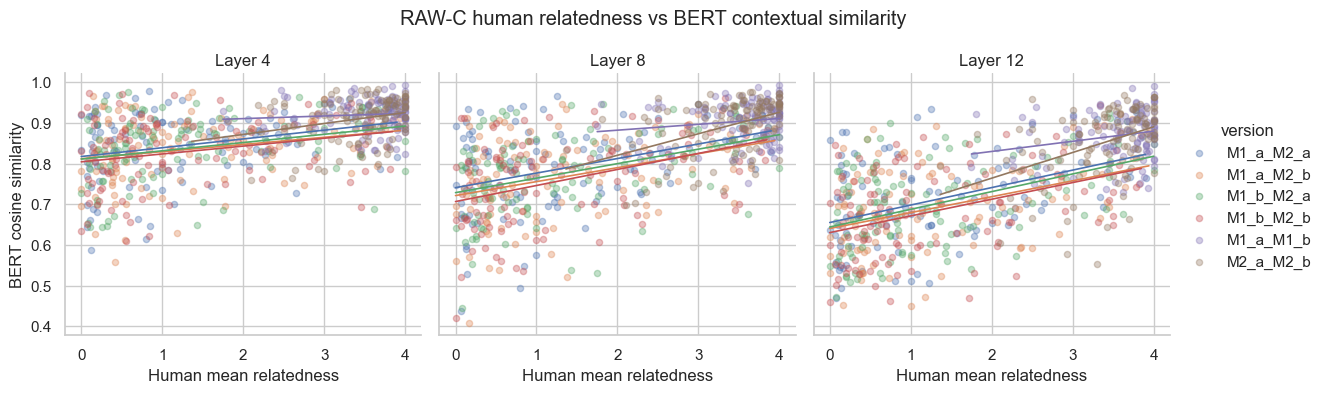

Saved plot to: c:\Users\digitalnomad\Downloads\projectcl\outputs\rawc_layer_correlations.png


,word,string,version,same,ambiguity_type,mean_relatedness,layer,cosine_similarity,same_label
0,act,act,M1_a_M2_a,False,Polysemy,2.181818,Layer 4,0.883542,different sense
1,act,act,M1_a_M2_b,False,Polysemy,2.000000,Layer 4,0.857138,different sense
2,act,act,M1_b_M2_a,False,Polysemy,2.818182,Layer 4,0.883542,different sense
3,act,act,M1_b_M2_b,False,Polysemy,2.809524,Layer 4,0.793135,different sense
4,act,act,M1_a_M1_b,True,Polysemy,3.900000,Layer 4,0.883749,same sense


In [39]:
# Visualize correlations by BERT layer and meaning contrast.
import matplotlib.pyplot as plt
import seaborn as sns

pair_long_df = pair_similarity_df.melt(
    id_vars=["word", "string", "version", "same", "ambiguity_type", "mean_relatedness"],
    value_vars=["similarity_l4", "similarity_l8", "similarity_l12"],
    var_name="layer",
    value_name="cosine_similarity",
)
pair_long_df["layer"] = pair_long_df["layer"].str.replace("similarity_l", "Layer ", regex=False)
pair_long_df["same_label"] = pair_long_df["same"].map({True: "same sense", False: "different sense"})

sns.set_theme(style="whitegrid")
g = sns.lmplot(
    data=pair_long_df,
    x="mean_relatedness",
    y="cosine_similarity",
    col="layer",
    hue="version",
    col_order=["Layer 4", "Layer 8", "Layer 12"],
    height=4,
    aspect=1,
    scatter_kws={"alpha": 0.35, "s": 20},
    line_kws={"linewidth": 1.2},
    ci=None,
)
g.set_axis_labels("Human mean relatedness", "BERT cosine similarity")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("RAW-C human relatedness vs BERT contextual similarity")
plot_path = OUTPUT_DIR / "rawc_layer_correlations.png"
g.fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved plot to:", plot_path)

display(pair_long_df.head())

### Reflect on the correlations and on the visualisations. What can you observe and infer in terms of which layer(s) might be capturing meaning best? Is there one way to determine that (i.e., what does 'capturing meanings' mean?)? Contrast and compare the layers. [5 points]

The Spearman correlations with human mean relatedness increase across the tested contextual layers: **layer 4 rho = 0.488**, **layer 8 rho = 0.631**, and **layer 12 rho = 0.672**. All three correlations are positive and have very small p-values, so all layers capture some information that aligns with human relatedness judgements, but layer 12 aligns best with humans in this replication.

The visualization also shows why the higher layers look better: same-sense pairs tend to receive higher BERT cosine similarities than different-sense pairs, and this separation becomes clearer in later layers. The mean similarities show the same pattern. At layer 4, same-sense pairs average **0.915** and different-sense pairs average **0.837**, a fairly compressed difference. At layer 12, same-sense pairs average **0.860** and different-sense pairs average **0.698**, giving a wider separation between meanings.

There is not just one way to define "capturing meaning". If the criterion is alignment with human graded relatedness, layer 12 is best here. If the criterion is whether individual contexts map to plausible WordNet glosses, the picture is messier: for example, `bank` looked more balanced at layer 8, while the dominant-sense analysis had low match rates for every layer. I therefore conclude that later BERT layers, especially layer 12, best capture human-like relatedness in the RAW-C pair task, but WordNet-nearest-sense behavior should be interpreted more cautiously.